# Aviation Accident Data Analysis

This notebook explores a historical aviation accident dataset using `pandas`, `numpy`, and `matplotlib`.

The goal is to make the analysis clear and reproducible. The notebook answers a few practical questions:

- Which countries have the most recorded accidents?
- Which weekdays appear most often in dated accident records?
- Which operators and aircraft types have the largest recorded totals?
- How did accident counts and recorded fatalities change over time?
- How strong is the relationship between annual accident counts and annual recorded fatalities?

Important limitation: this dataset contains accident records only. It does not include flight volume, fleet size, route exposure, or aircraft age, so the results should not be interpreted as safety rankings.


## 1. Setup

The notebook keeps dependencies intentionally small so it can run in a standard Python data-analysis environment.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

DATA_URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/aviation-accidents.csv"
LOCAL_DATA_PATH = Path("aviation-accidents.csv")


## 2. Load the Dataset

The code uses a local CSV file when it is available, otherwise it downloads the dataset from the source URL. This makes the notebook work both inside a GitHub repository and in a fresh notebook environment.


In [2]:
data_source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.exists() else DATA_URL
raw_df = pd.read_csv(data_source)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
display(raw_df.head())


Rows: 23,967
Columns: 9


,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


In [3]:
raw_profile = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_values": raw_df.isna().sum(),
        "missing_pct": (raw_df.isna().mean() * 100).round(2),
    }
)

display(raw_profile)


,dtype,missing_values,missing_pct
date,object,0,0.00
type,object,0,0.00
registration,object,1548,6.46
operator,object,4,0.02
fatalities,object,3938,16.43
location,object,948,3.96
country,object,0,0.00
cat,object,0,0.00
year,object,0,0.00


## 3. Clean the Data

The raw data stores several numeric fields as text. Some fatality values are written as sums such as `"5+ 1"`, while unknown years and countries use text placeholders. Dates can also contain incomplete values with question marks.

The cleaning step below:

- converts fatalities to numeric totals while preserving missing values;
- converts valid years to integers and removes rows with unknown years;
- replaces `"Unknown country"` with a missing value;
- converts valid dates to `datetime` and keeps incomplete dates as missing;
- adds a weekday column for dated records.


In [4]:
def parse_fatalities(value):
    """Convert fatality strings such as "5+ 1" into numeric totals."""
    if pd.isna(value):
        return pd.NA

    text = str(value).strip()
    if not text or text.lower() in {"nan", "unknown"}:
        return pd.NA

    try:
        return sum(int(part.strip()) for part in text.split("+"))
    except ValueError:
        return pd.NA


def clean_aviation_data(frame):
    """Return a cleaned copy of the aviation accident dataset."""
    cleaned = frame.copy()

    cleaned["fatalities"] = cleaned["fatalities"].apply(parse_fatalities).astype("Int64")
    cleaned["year"] = pd.to_numeric(
        cleaned["year"].replace("unknown", pd.NA),
        errors="coerce",
    ).astype("Int64")
    cleaned["country"] = cleaned["country"].replace("Unknown country", pd.NA)

    incomplete_dates = cleaned["date"].astype("string").str.contains(r"\?", na=False)
    cleaned.loc[incomplete_dates, "date"] = pd.NA
    cleaned["date"] = pd.to_datetime(cleaned["date"], format="%d-%b-%Y", errors="coerce")

    cleaned = cleaned.dropna(subset=["year"]).reset_index(drop=True)
    cleaned["year"] = cleaned["year"].astype(int)
    cleaned["weekday"] = cleaned["date"].dt.day_name()

    return cleaned


df = clean_aviation_data(raw_df)


In [5]:
cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "raw rows",
            "clean rows",
            "rows removed because year is unknown",
            "records with known dates",
            "records with known fatalities",
        ],
        "value": [
            len(raw_df),
            len(df),
            len(raw_df) - len(df),
            df["date"].notna().sum(),
            df["fatalities"].notna().sum(),
        ],
    }
)

display(cleaning_summary)
display(df.head())


,metric,value
0,raw rows,23967
1,clean rows,23906
2,rows removed because year is unknown,61
3,records with known dates,23408
4,records with known fatalities,20004


,date,type,registration,operator,fatalities,location,country,cat,year,weekday
0,1919-08-02,Caproni Ca.48,NaN,Caproni,14,Verona,Italy,A1,1919,Saturday
1,1919-08-11,Felixstowe Fury,N123,RAF,1,near Felixtowe RNAS,U.K.,A1,1919,Monday
2,1920-02-23,Handley Page O/7,G-EANV,Handley Page Transport,0,"Acadia Siding, C...",South Africa,A1,1920,Monday
3,1920-02-25,Handley Page O/400,G-EAMC,Handley Page Transport,0,near El Shereik,Sudan,A1,1920,Wednesday
4,1920-06-30,Handley Page O/400,G-EAKE,Handley Page Transport,0,ÃstanÃ¥,Sweden,A1,1920,Wednesday


In [6]:
clean_profile = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    }
)

display(clean_profile)


,dtype,missing_values,missing_pct
date,datetime64[ns],498,2.08
type,object,0,0.00
registration,object,1545,6.46
operator,object,4,0.02
fatalities,Int64,3902,16.32
location,object,920,3.85
country,object,819,3.43
cat,object,0,0.00
year,int64,0,0.00
weekday,object,498,2.08


## 4. Countries with the Most Recorded Accidents

The United States has the largest number of recorded accidents in the dataset, followed by Russia and the U.K. This is a count of records, not a normalized accident rate.


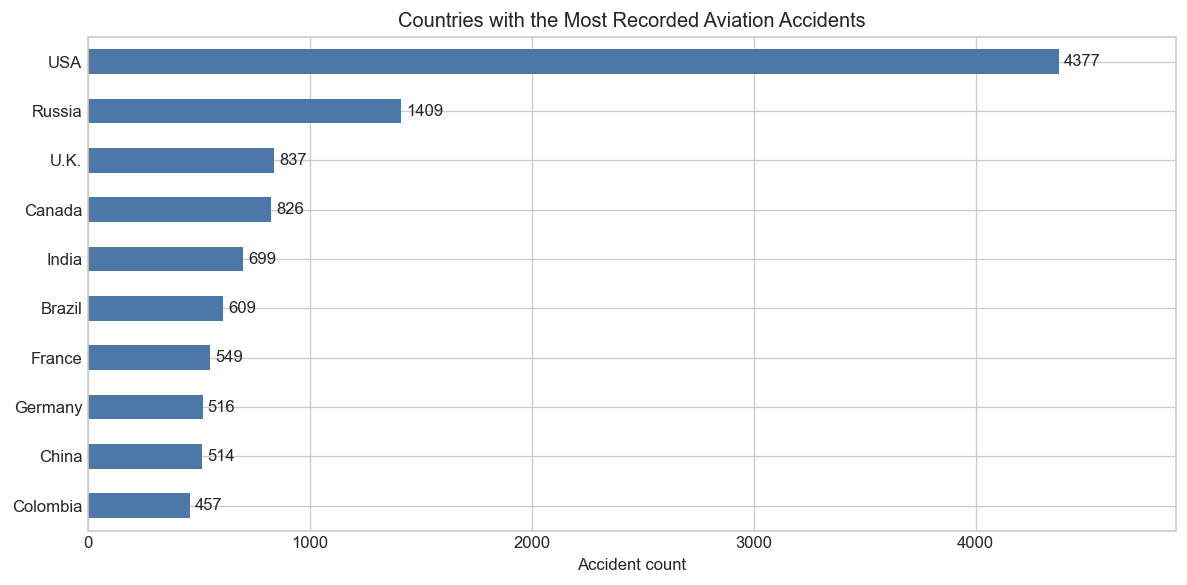

,country,accidents
0,USA,4377
1,Russia,1409
2,U.K.,837
3,Canada,826
4,India,699
5,Brazil,609
6,France,549
7,Germany,516
8,China,514
9,Colombia,457


In [7]:
top_countries = df["country"].value_counts(dropna=True).head(10)
top_countries_table = top_countries.rename_axis("country").reset_index(name="accidents")

fig, ax = plt.subplots(figsize=(10, 5))
top_countries.sort_values().plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Countries with the Most Recorded Aviation Accidents")
ax.set_xlabel("Accident count")
ax.set_ylabel("")
ax.set_xlim(0, top_countries.max() * 1.12)
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

display(top_countries_table)


## 5. Accident Records by Weekday

Friday is the most frequent weekday among records with a valid date. The differences between weekdays are relatively modest, and records without complete dates are excluded from this view.


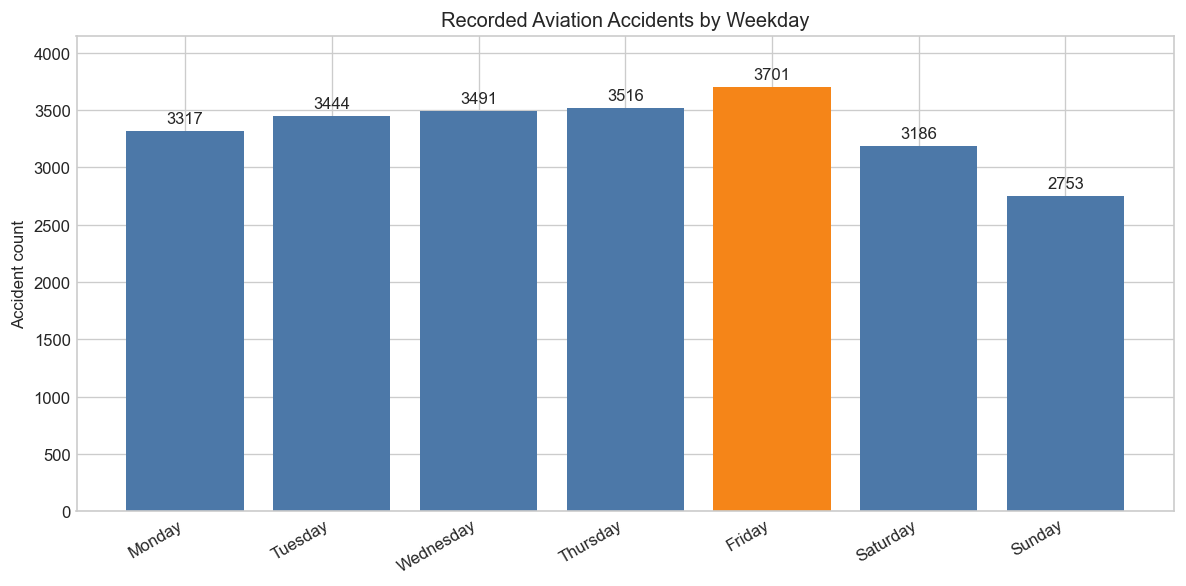

,weekday,accidents
0,Monday,3317
1,Tuesday,3444
2,Wednesday,3491
3,Thursday,3516
4,Friday,3701
5,Saturday,3186
6,Sunday,2753


In [8]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = df["weekday"].value_counts().reindex(weekday_order)

colors = ["#4C78A8" if day != weekday_counts.idxmax() else "#F58518" for day in weekday_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(weekday_counts.index, weekday_counts.values, color=colors)
ax.set_title("Recorded Aviation Accidents by Weekday")
ax.set_xlabel("")
ax.set_ylabel("Accident count")
ax.set_ylim(0, weekday_counts.max() * 1.12)
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(weekday_counts.rename_axis("weekday").reset_index(name="accidents"))


## 6. Operators

The next table ranks operators by total recorded fatalities in this accident dataset. These totals are not safety scores because the dataset does not include exposure metrics such as total flights, passenger volume, or fleet size.

The second table shows examples of operators with exactly one recorded accident and zero recorded fatalities. They should be read as low-fatality examples in this dataset, not as the "safest" operators overall.


In [9]:
operator_groups = df.dropna(subset=["operator"]).groupby("operator")
operator_summary = operator_groups.agg(
    accidents=("operator", "size"),
    known_fatality_records=("fatalities", "count"),
)
operator_summary["recorded_fatalities"] = operator_groups["fatalities"].sum(min_count=1)
operator_summary["avg_fatalities_per_accident"] = (
    operator_summary["recorded_fatalities"] / operator_summary["accidents"]
).round(2)

top_fatal_operators = (
    operator_summary.dropna(subset=["recorded_fatalities"])
    .sort_values(["recorded_fatalities", "accidents"], ascending=False)
    .head(10)
)

low_fatality_examples = (
    operator_summary[
        (operator_summary["accidents"] == 1)
        & (operator_summary["known_fatality_records"] == 1)
        & (operator_summary["recorded_fatalities"] == 0)
    ]
    .sort_index()
    .head(10)
)

display(top_fatal_operators)
display(low_fatality_examples)


,accidents,known_fatality_records,recorded_fatalities,avg_fatalities_per_accident
operator,,,,
USAF,1120,959,5905,5.27
USAAF,2603,851,4616,1.77
American Airlines,116,116,3164,27.28
US Navy,745,500,2849,3.82
RAF,920,716,2632,2.86
United Airlines,100,99,2071,20.71
Air France,138,124,1676,12.14
Pan Am,92,92,1663,18.08
Soviet AF,134,120,1271,9.49


,accidents,known_fatality_records,recorded_fatalities,avg_fatalities_per_accident
operator,,,,
", op.for UN",1,1,0,0.0
1982-047 LLC,1,1,0,0.0
2M Leasing,1,1,0,0.0
40-Mile Air,1,1,0,0.0
987 Investments,1,1,0,0.0
A.R. Wings,1,1,0,0.0
AAA Investments,1,1,0,0.0
ABA Aviation Resources,1,1,0,0.0
ABS Equipment Leasing,1,1,0,0.0


## 7. Aircraft Types

The Douglas C-47A (DC-3) appears most often by accident count and also has the highest total recorded fatalities in this dataset. This likely reflects historical usage and exposure, so it should not be interpreted as an aircraft risk rate.


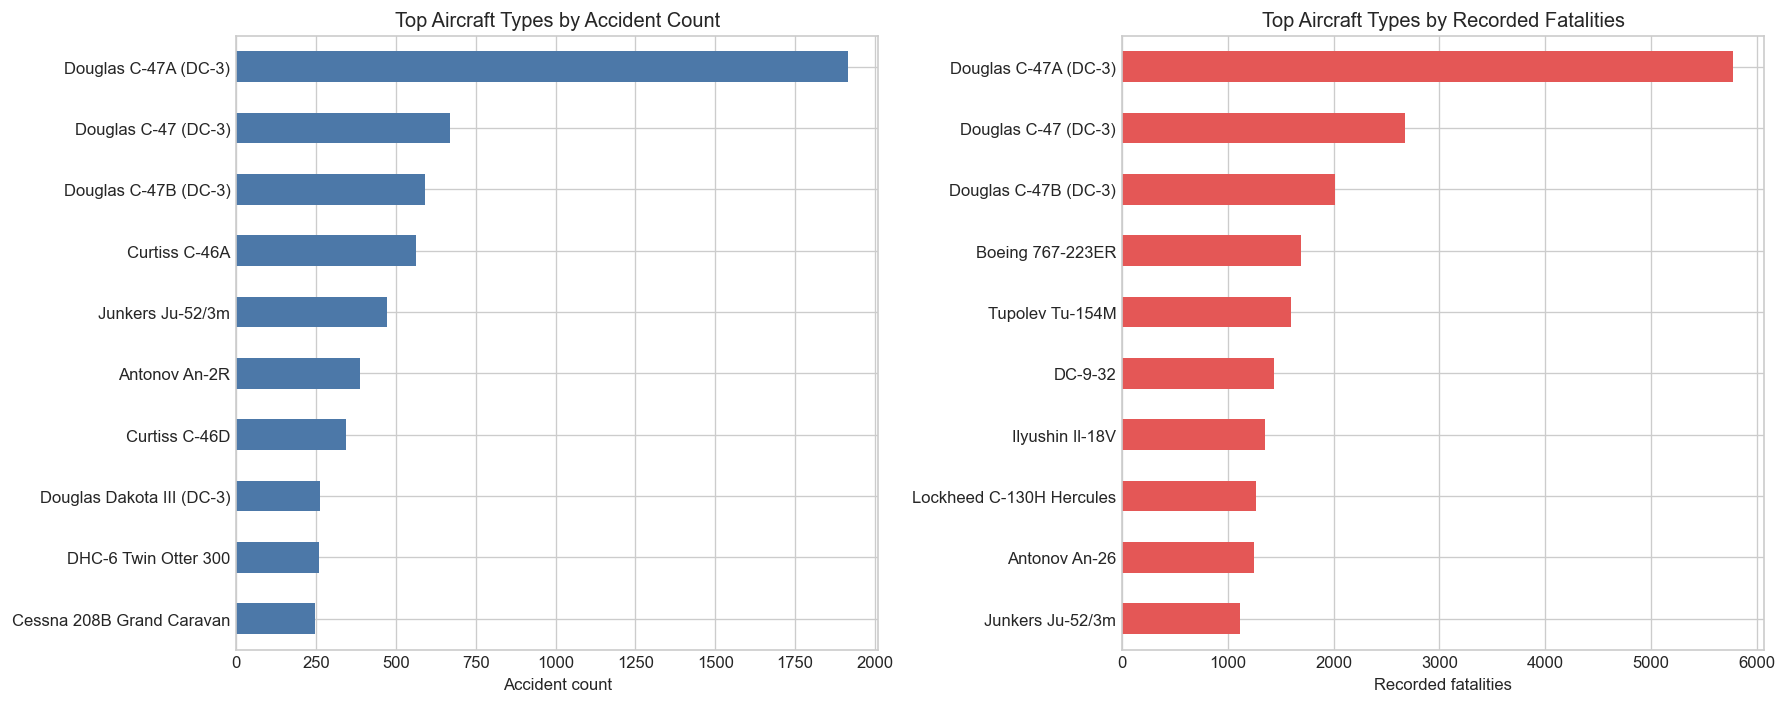

,accidents,known_fatality_records,recorded_fatalities
type,,,
Douglas C-47A (DC-3),1915,1104,5780
Douglas C-47 (DC-3),669,404,2676
Douglas C-47B (DC-3),592,366,2017
Curtiss C-46A,564,238,869
Junkers Ju-52/3m,471,237,1114
Antonov An-2R,389,300,291
Curtiss C-46D,344,143,903
Douglas Dakota III (DC-3),262,145,668
DHC-6 Twin Otter 300,258,252,1056


,accidents,known_fatality_records,recorded_fatalities
type,,,
Douglas C-47A (DC-3),1915,1104,5780
Douglas C-47 (DC-3),669,404,2676
Douglas C-47B (DC-3),592,366,2017
Boeing 767-223ER,2,2,1692
Tupolev Tu-154M,34,34,1600
DC-9-32,67,67,1441
Ilyushin Il-18V,53,50,1356
Lockheed C-130H Hercules,73,68,1271
Antonov An-26,133,117,1246


In [10]:
type_groups = df.groupby("type")
type_summary = type_groups.agg(
    accidents=("type", "size"),
    known_fatality_records=("fatalities", "count"),
)
type_summary["recorded_fatalities"] = type_groups["fatalities"].sum(min_count=1)

top_types_by_accidents = type_summary.sort_values("accidents", ascending=False).head(10)
top_types_by_fatalities = (
    type_summary.dropna(subset=["recorded_fatalities"])
    .sort_values("recorded_fatalities", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_types_by_accidents["accidents"].sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].set_title("Top Aircraft Types by Accident Count")
axes[0].set_xlabel("Accident count")
axes[0].set_ylabel("")

top_types_by_fatalities["recorded_fatalities"].sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="#E45756",
)
axes[1].set_title("Top Aircraft Types by Recorded Fatalities")
axes[1].set_xlabel("Recorded fatalities")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(top_types_by_accidents)
display(top_types_by_fatalities)


## 8. Trends over Time

Accident counts peak during World War II, especially 1944 and 1945. Recorded fatalities peak in 2001, while accident counts do not peak that year, showing that frequency and severity can move differently.


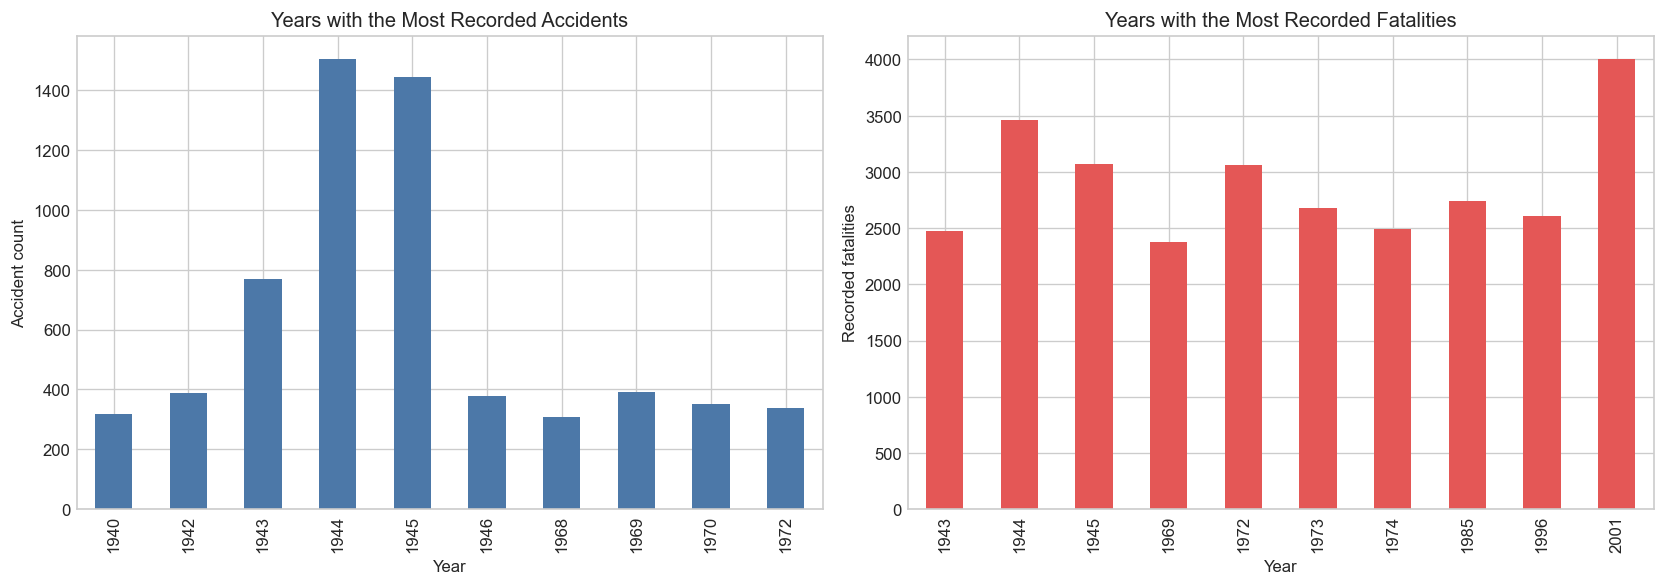

,accidents,recorded_fatalities
year,,
1944,1505,3462
1945,1445,3069
1943,769,2477
1969,393,2380
1942,389,1354
1946,379,1530
1970,351,2036
1972,339,3060
1940,318,462


,accidents,recorded_fatalities
year,,
2001,226,4007
1944,1505,3462
1945,1445,3069
1972,339,3060
1985,219,2737
1973,293,2683
1996,253,2610
1974,254,2492
1943,769,2477


In [11]:
annual_accidents = df.groupby("year").size().rename("accidents")
annual_fatalities = df.groupby("year")["fatalities"].sum(min_count=1).rename("recorded_fatalities")
annual_summary = pd.concat([annual_accidents, annual_fatalities], axis=1).fillna({"recorded_fatalities": 0})

top_years_by_accidents = annual_summary.sort_values("accidents", ascending=False).head(10)
top_years_by_fatalities = annual_summary.sort_values("recorded_fatalities", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_years_by_accidents["accidents"].sort_index().plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Years with the Most Recorded Accidents")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Accident count")

top_years_by_fatalities["recorded_fatalities"].sort_index().plot(kind="bar", ax=axes[1], color="#E45756")
axes[1].set_title("Years with the Most Recorded Fatalities")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Recorded fatalities")

plt.tight_layout()
plt.show()

display(top_years_by_accidents)
display(top_years_by_fatalities)


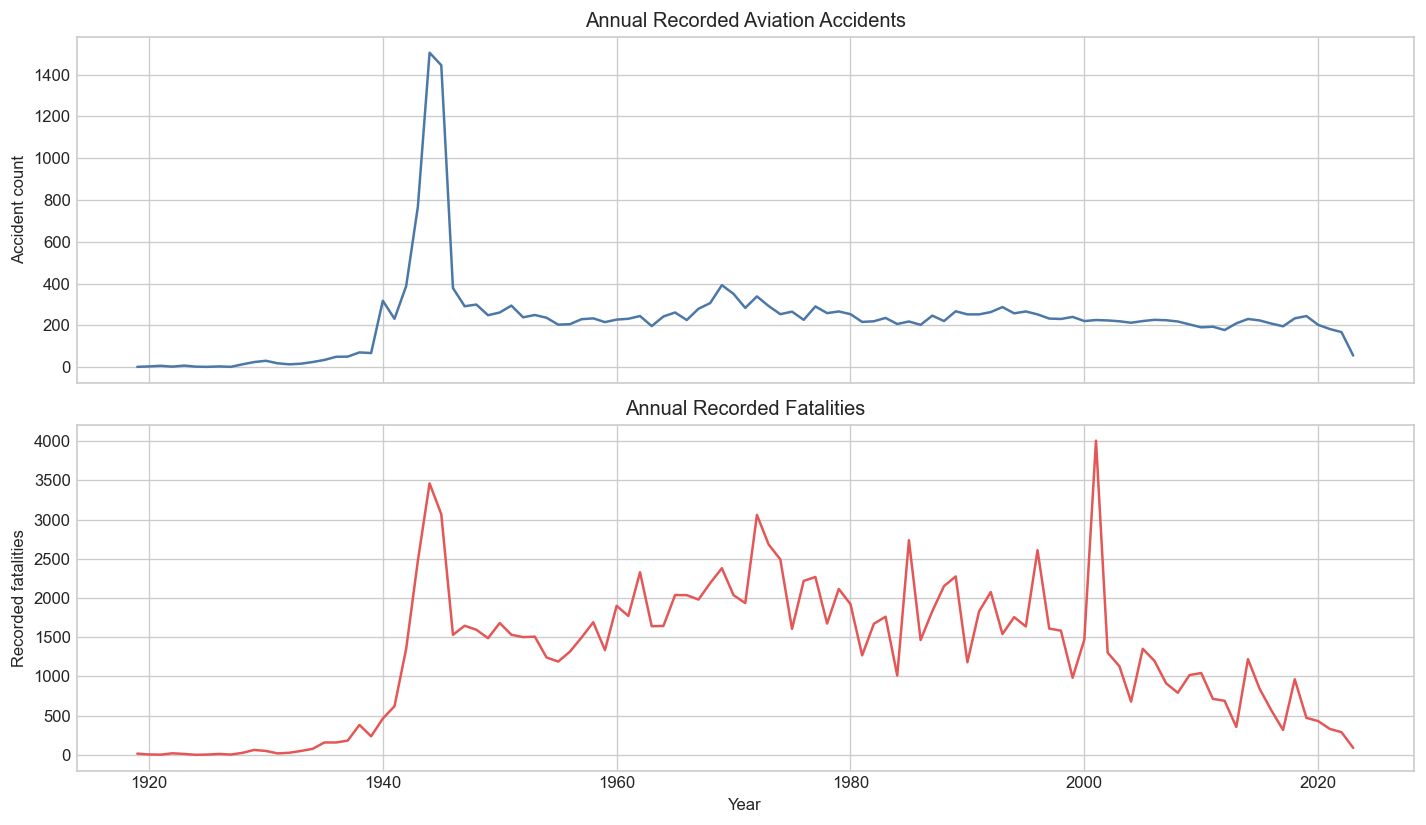

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

annual_summary["accidents"].plot(ax=axes[0], color="#4C78A8")
axes[0].set_title("Annual Recorded Aviation Accidents")
axes[0].set_ylabel("Accident count")

annual_summary["recorded_fatalities"].plot(ax=axes[1], color="#E45756")
axes[1].set_title("Annual Recorded Fatalities")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Recorded fatalities")

plt.tight_layout()
plt.show()


## 9. Accident Counts vs. Recorded Fatalities

Annual accident counts and annual recorded fatalities have a positive relationship, but it is not strong enough to treat accident frequency as a complete explanation of fatalities. A small number of severe events can change annual fatalities substantially.


Pearson correlation: 0.64


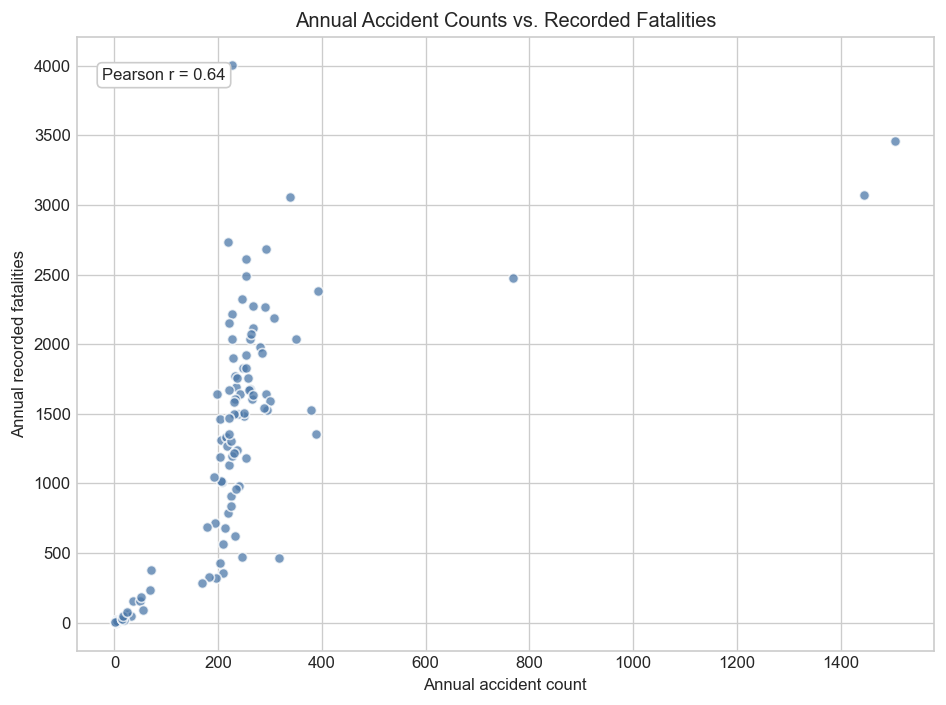

In [13]:
correlation = annual_summary["accidents"].corr(annual_summary["recorded_fatalities"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    annual_summary["accidents"],
    annual_summary["recorded_fatalities"],
    alpha=0.75,
    color="#4C78A8",
    edgecolor="white",
)
ax.set_title("Annual Accident Counts vs. Recorded Fatalities")
ax.set_xlabel("Annual accident count")
ax.set_ylabel("Annual recorded fatalities")
ax.text(
    0.03,
    0.95,
    f"Pearson r = {correlation:.2f}",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "#cccccc"},
)
plt.tight_layout()
plt.show()

print(f"Pearson correlation: {correlation:.2f}")


## 10. Key Takeaways

- The dataset contains 23,906 accident records after removing rows with unknown years.
- The United States has the largest number of recorded accidents, followed by Russia and the U.K.
- Friday is the most frequent weekday among records with a complete date, but the weekday differences are not large.
- Accident counts peak in the World War II period, especially 1944 and 1945.
- Recorded fatalities peak in 2001, which highlights the difference between accident frequency and accident severity.
- Operator and aircraft type rankings are descriptive counts from an accident dataset, not normalized safety or risk rates.

For a stronger risk analysis, the next step would be to combine this dataset with exposure metrics such as departures, passenger volume, aircraft fleet size, and operating years.
